# Sommeil_EOG_IA - Classification automatique des stades du sommeil par IA

**Projet :** scoring polysomnographique a partir d'un seul canal **EOG** (electro-oculographie).

**Modele deploye :** reseau de neurones convolutif **1D (CNN)**, exporte en **OpenVINO IR FP16** pour
l'inference acceleree (NPU Intel AI Boost / GPU integre / CPU).

**Interface :** tableau de bord clinique **Streamlit DeepSleep AI**.

Les cinq stades suivent la nomenclature **AASM** : `W` (eveil), `N1`, `N2`, `N3` (sommeil profond), `REM` (paradoxal).

---
## Sommaire
1. Contexte et objectifs
2. Configuration et imports
3. Donnees EDF et nomenclature AASM
4. Pretraitement du signal EOG
5. Morphologie du signal par stade
6. Architecture du modele (CNN 1D NPU)
7. Decoupage par sujet et protocole d'entrainement
8. Inference acceleree OpenVINO
9. Evaluation et metriques (cas reel Patient_01)
10. Resultats sur le jeu de test hold-out (27 sujets)
11. Conclusion

> **Note d'execution.** Les cellules de demonstration (pretraitement, inference, evaluation) sont
> directement executables et reposent sur l'enregistrement `data/raw/Patient_01` (reserve au jeu de test).
> L'entrainement complet (corpus de 419 170 epoques) a ete realise sur GPU Kaggle ; il est ici **documente**
> mais non re-execute pour des raisons de temps et de memoire.

## 1. Contexte et objectifs

La polysomnographie (PSG) enregistre plusieurs signaux physiologiques durant une nuit. Le *scoring* manuel
des stades de sommeil, fenetre par fenetre de 30 s, est long et sujet a variabilite inter-juges.
Le signal **EOG** capte les mouvements oculaires, tres informatifs pour distinguer l'eveil et le sommeil
paradoxal (REM).

**Objectifs du projet :**
- Charger et synchroniser signaux + annotations au format **EDF** (MNE-Python).
- Pretraiter le canal EOG : reechantillonnage 100 Hz, filtrage 0,5-35 Hz, normalisation z-score.
- Entrainer un classifieur d'epoques de 30 s sur les **5 classes AASM**, avec **decoupage par sujet**.
- Exporter un modele compatible **NPU** via OpenVINO (FP16, entree fixe 64x3000x1).
- Fournir un **dashboard** interactif pour l'analyse et la comparaison a l'expert.

## 2. Configuration et imports

On localise la racine du projet (dossier contenant `src/`), puis on importe les modules du projet et les
bibliotheques scientifiques. Le pipeline d'inference n'a besoin que de **NumPy, MNE et OpenVINO** (pas de
TensorFlow a l'execution).

In [1]:
import os
import sys
import json
import time

import numpy as np
import matplotlib.pyplot as plt


def find_root(start=None):
    """Remonte l'arborescence jusqu'au dossier contenant 'src'."""
    d = os.path.abspath(start or os.getcwd())
    for _ in range(6):
        if os.path.isdir(os.path.join(d, 'src')) and os.path.isdir(os.path.join(d, 'models')):
            return d
        d = os.path.dirname(d)
    return os.path.abspath(os.path.join(os.getcwd(), '..'))


ROOT = find_root()
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'src'))
print('Racine du projet :', ROOT)

STAGES = ['W', 'N1', 'N2', 'N3', 'REM']
STAGE_COLORS = ['#EAB308', '#93C5E8', '#3B82B6', '#0C4A6E', '#B91C1C']
N_POINTS = 3000   # 30 s x 100 Hz
BATCH = 64        # batch fixe attendu par le modele IR
plt.rcParams['figure.dpi'] = 110

Racine du projet : C:\Users\raish\OneDrive\Desktop\Dossier\Projects\Sommeil_EOG_IA


## 3. Donnees EDF et nomenclature AASM

Le corpus principal est **Sleep-EDF Expanded** (PhysioNet), complete par 4 enregistrements locaux
(`Patient_01/02/11/12`). Chaque sujet fournit un fichier *signal* (`*-PSG.edf` / `*_Signal.edf`) et un
*hypnogramme* expert (`*-Hypnogram.edf` / `*_Labels.edf`). Le module `src/data_loader.py` convertit les
annotations textuelles en codes de stade via la table de correspondance AASM (N3 et N4 fusionnes).

In [2]:
from data_loader import STAGE_MAP, TARGET_SFREQ, EPOCH_DURATION, N_SAMPLES_PER_EPOCH

print('Frequence cible      :', TARGET_SFREQ, 'Hz')
print('Duree epoque         :', EPOCH_DURATION, 's')
print('Points par epoque    :', N_SAMPLES_PER_EPOCH)
print('Correspondance AASM  :', STAGE_MAP, '(3 et 4 -> N3)')

raw_dir = os.path.join(ROOT, 'data', 'raw')
print('\nEnregistrements de demonstration disponibles :')
for f in sorted(os.listdir(raw_dir)):
    if f.endswith('.edf'):
        print('  -', f)

Frequence cible      : 100.0 Hz
Duree epoque         : 30.0 s
Points par epoque    : 3000
Correspondance AASM  : {'W': 0, '1': 1, '2': 2, '3': 3, '4': 3, 'R': 4} (3 et 4 -> N3)

Enregistrements de demonstration disponibles :
  - Patient_01_Labels.edf
  - Patient_01_Signal.edf
  - Patient_02_Labels.edf
  - Patient_02_Signal.edf
  - Patient_11_Labels.edf
  - Patient_11_Signal.edf
  - Patient_12_Labels.edf
  - Patient_12_Signal.edf


## 4. Pretraitement du signal EOG

Le module `src/preprocessing.py` homogeneise les enregistrements avant l'inference :

1. **Reechantillonnage** a 100 Hz (entree du modele).
2. **Selection automatique** du premier canal dont le nom contient `EOG`.
3. **Filtrage** passe-bande FIR 0,5-35 Hz (derive lente + bruit haute frequence).
4. **Normalisation** z-score par enregistrement, puis ecretage a +/-3 ecarts-types.

On charge `Patient_01`, on applique le pretraitement, puis on decoupe en epoques de 30 s -> tenseur `(N, 3000, 1)`.

In [3]:
import mne
mne.set_log_level('ERROR')
from preprocessing import apply_preprocessing
from data_loader import load_and_sync_labels

sig_path = os.path.join(raw_dir, 'Patient_01_Signal.edf')
lab_path = os.path.join(raw_dir, 'Patient_01_Labels.edf')

raw = mne.io.read_raw_edf(sig_path, preload=True, verbose=False)
raw_100 = raw.copy().resample(100.0) if raw.info['sfreq'] != 100.0 else raw.copy()
eog_name = [c for c in raw.ch_names if 'EOG' in c.upper()][0]
signal_brut = raw_100.get_data(picks=[eog_name])[0]

signal_proc, eog_ch = apply_preprocessing(raw)
n_epochs = len(signal_proc) // N_POINTS
X = signal_proc[:n_epochs * N_POINTS].reshape(n_epochs, N_POINTS, 1).astype(np.float32)
y_true = load_and_sync_labels(lab_path, n_epochs)

print('Canal EOG selectionne :', eog_ch)
print('Duree enregistrement  : %.1f h' % (len(signal_proc) / 100.0 / 3600))
print('Nombre d epoques      :', n_epochs)
print('Forme du tenseur X    :', X.shape)
print('Distribution stades   :', dict(zip(STAGES, np.bincount(y_true[y_true >= 0], minlength=5))))

Canal EOG selectionne : EOG horizontal
Duree enregistrement  : 22.1 h
Nombre d epoques      : 2650
Forme du tenseur X    : (2650, 3000, 1)
Distribution stades   : {'W': 1997, 'N1': 58, 'N2': 250, 'N3': 220, 'REM': 125}


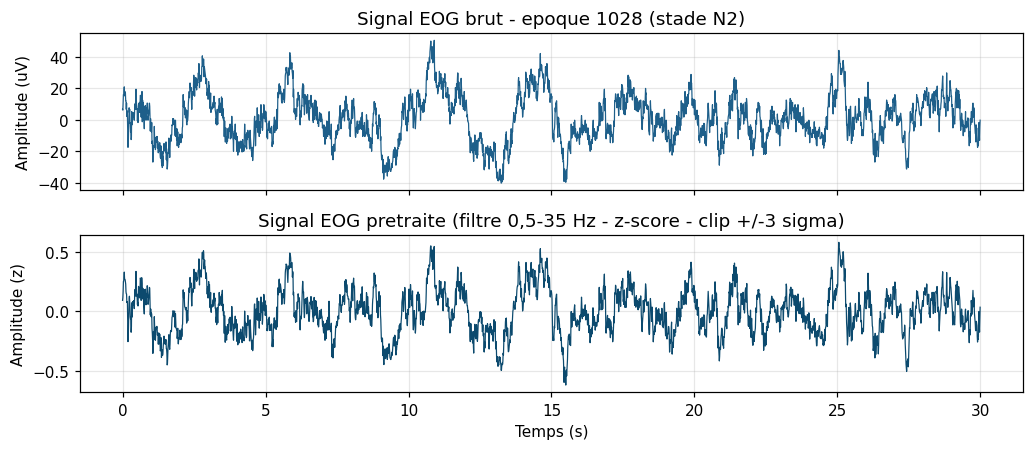

In [4]:
# Effet du pretraitement sur une epoque (stade N2 si present)
target = 2 if (y_true == 2).any() else int(np.bincount(y_true[y_true >= 0]).argmax())
idx = int(np.where(y_true == target)[0][3])
s = idx * N_POINTS
t = np.arange(N_POINTS) / 100.0

fig, ax = plt.subplots(2, 1, figsize=(9.5, 4.2), sharex=True)
ax[0].plot(t, signal_brut[s:s + N_POINTS] * 1e6, color='#1E5F8A', lw=0.8)
ax[0].set_title('Signal EOG brut - epoque %d (stade %s)' % (idx, STAGES[target]))
ax[0].set_ylabel('Amplitude (uV)'); ax[0].grid(alpha=0.3)
ax[1].plot(t, signal_proc[s:s + N_POINTS], color='#0C4A6E', lw=0.8)
ax[1].set_title('Signal EOG pretraite (filtre 0,5-35 Hz - z-score - clip +/-3 sigma)')
ax[1].set_ylabel('Amplitude (z)'); ax[1].set_xlabel('Temps (s)'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Morphologie du signal par stade

Chaque stade presente une signature differente sur l'EOG : forte activite a l'eveil (W), mouvements
oculaires rapides en REM, signal calme en sommeil profond (N3). C'est cette structure que le reseau apprend a discriminer.

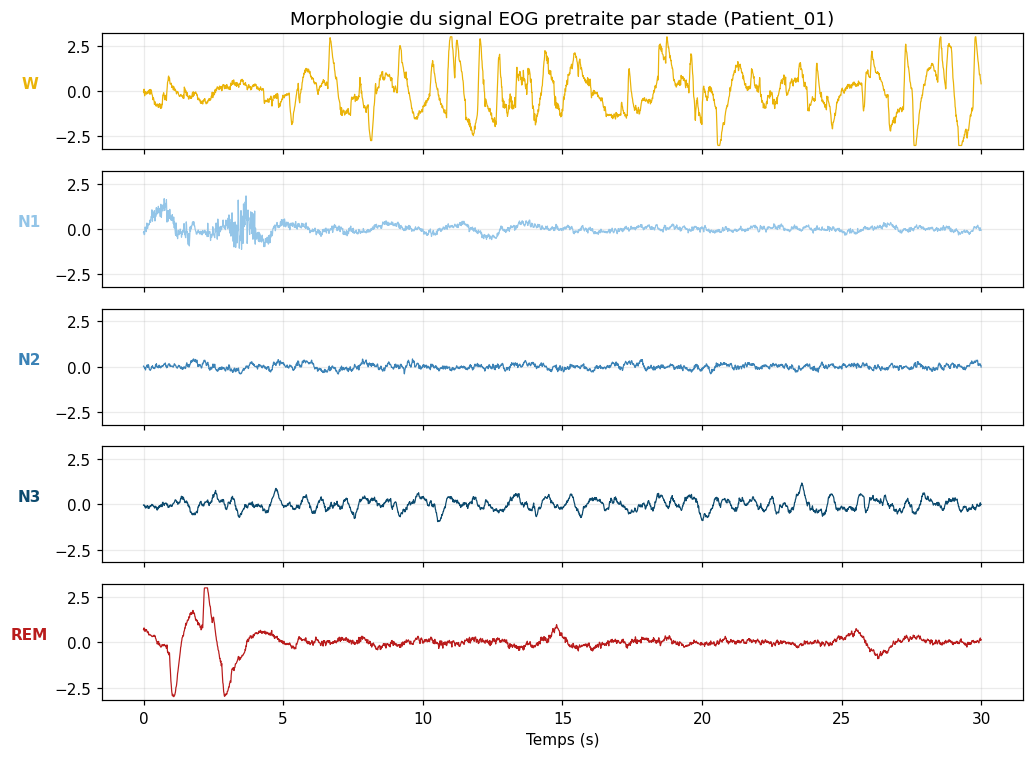

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(9.5, 7.0), sharex=True)
for k in range(5):
    where = np.where(y_true == k)[0]
    if len(where):
        j = int(where[len(where) // 2])
        axes[k].plot(t, signal_proc[j * N_POINTS:j * N_POINTS + N_POINTS], color=STAGE_COLORS[k], lw=0.8)
    else:
        axes[k].text(0.5, 0.5, 'absent', ha='center', va='center', transform=axes[k].transAxes)
    axes[k].set_ylabel(STAGES[k], rotation=0, labelpad=16, color=STAGE_COLORS[k], fontweight='bold')
    axes[k].set_ylim(-3.2, 3.2); axes[k].grid(alpha=0.25)
axes[0].set_title('Morphologie du signal EOG pretraite par stade (Patient_01)')
axes[-1].set_xlabel('Temps (s)')
plt.tight_layout(); plt.show()

## 6. Architecture du modele (CNN 1D NPU)

Deux architectures sont definies dans `src/architecture.py` :
- **CNN + Bi-LSTM** : meilleure modelisation temporelle, mais operations recurrentes (`Loop`,
  `ReverseSequence`) **non supportees par le NPU** Intel cible.
- **CNN 1D pur** (deploye) : 4 blocs `Conv1D + BatchNorm + MaxPooling`, puis `GlobalAveragePooling` et
  couches denses. Environ **455 000 parametres**, entree statique `(64, 3000, 1)`.

L'affichage du resume necessite TensorFlow (`requirements-train.txt`). Si TensorFlow est absent, on saute
cette cellule : le modele effectivement utilise pour l'inference est le fichier OpenVINO (section 8).

In [6]:
try:
    from architecture import build_cnn_npu_model
    model = build_cnn_npu_model(input_shape=(N_POINTS, 1))
    model.summary()
    print('\nParametres totaux :', f"{model.count_params():,}")
except Exception as e:
    print('TensorFlow indisponible (normal pour l inference seule) :', type(e).__name__)
    print('Voir src/architecture.py pour la definition complete du modele.')

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv1d (Conv1D)             (None, 3000, 64)          768       


 batch_normalization (Batch  (None, 3000, 64)          256       


...

Total params: 455557 (1.74 MB)


Trainable params: 454149 (1.73 MB)


Non-trainable params: 1408 (5.50 KB)


_________________________________________________________________



Parametres totaux : 455,557


## 7. Decoupage par sujet et protocole d'entrainement

Point methodologique **central** : le decoupage est realise **par sujet** (`src/splits.py`), jamais par
epoque. Ainsi, aucune epoque d'un sujet de test n'apparait a l'entrainement -> pas de fuite de donnees et
estimation honnete de la generalisation. Les sujets `Patient_01/02` sont **forces** dans le jeu de test
(demonstration devant le jury).

L'entrainement (perte = entropie croisee, optimiseur Adam, ponderation des classes, arret anticipe sur le
F1 macro) a ete mene sur **GPU Kaggle P100**. Le meilleur modele atteint **F1 macro ~= 0,724** en validation.

In [7]:
split_path = os.path.join(ROOT, 'data', 'processed', 'subject_split.json')
with open(split_path, encoding='utf-8') as f:
    split = json.load(f)

print('Decoupage par sujet (seed = %d) :' % split['seed'])
for fold in ('train', 'val', 'test'):
    print('  %-5s : %3d sujets  -  %7d epoques'
          % (fold, split['n_subjects_%s' % fold], split['n_epochs_%s' % fold]))
print('\nSujets forces dans le test (demo jury) :', split['forced_test_subjects'])
print('Total :', split['n_subjects_total'], 'sujets -',
      split['n_epochs_train'] + split['n_epochs_val'] + split['n_epochs_test'], 'epoques')

Decoupage par sujet (seed = 42) :
  train : 127 sujets  -   297012 epoques
  val   :  28 sujets  -    58045 epoques
  test  :  27 sujets  -    64113 epoques

Sujets forces dans le test (demo jury) : ['Patient_01', 'Patient_02']
Total : 182 sujets - 419170 epoques


## 8. Inference acceleree OpenVINO

Le modele Keras est exporte en **OpenVINO IR FP16** (`models/sleep_model_npu.xml` + `.bin`, ~0,9 Mo).
OpenVINO selectionne le meilleur accelerateur disponible. Ici, on force **CPU** (portable et disponible
partout) ; sur une machine equipee, il suffit de remplacer `'CPU'` par `'NPU'`, `'GPU'` ou `'AUTO'`.
L'inference est traitee par lots de 64 epoques.

In [8]:
import openvino as ov

DEVICE = 'CPU'  # remplacer par 'NPU' / 'GPU' / 'AUTO' selon le materiel
core = ov.Core()
print('Peripheriques OpenVINO detectes :', core.available_devices)

ir_model = core.read_model(os.path.join(ROOT, 'models', 'sleep_model_npu.xml'))
ir_model.reshape({ir_model.inputs[0]: [BATCH, N_POINTS, 1]})
net = core.compile_model(ir_model, DEVICE)

pad = (-n_epochs) % BATCH
X_pad = np.concatenate([X, np.zeros((pad, N_POINTS, 1), np.float32)]) if pad else X
key = net.output(0)

t0 = time.time()
logits = np.concatenate([net(X_pad[i:i + BATCH])[key] for i in range(0, len(X_pad), BATCH)])[:n_epochs]
dt = time.time() - t0

preds = np.argmax(logits, axis=1)
confs = np.max(logits, axis=1)
print('Peripherique utilise  :', DEVICE)
print('Inference             : %.0f ms pour %d epoques (%.0f epoques/s)' % (dt * 1000, n_epochs, n_epochs / dt))
print('Confiance moyenne     : %.1f %%' % (confs.mean() * 100))

Peripheriques OpenVINO detectes : ['CPU', 'GPU', 'NPU']


Peripherique utilise  : CPU
Inference             : 3974 ms pour 2650 epoques (667 epoques/s)
Confiance moyenne     : 92.5 %


## 9. Evaluation et metriques (cas reel Patient_01)

On compare les predictions de l'IA a l'hypnogramme **expert** de `Patient_01` : exactitude, F1 macro,
kappa de Cohen, matrice de confusion et hypnogrammes superposes.

In [9]:
from metrics import compute_metrics, print_metrics

valid = y_true >= 0
m = compute_metrics(y_true[valid], preds[valid])
print_metrics(m, title='Patient_01 - IA vs expert')


=== Patient_01 - IA vs expert ===
  Échantillons : 2650
  Accuracy     : 0.9230
  F1 macro     : 0.7628
  F1 weighted  : 0.9329
  Cohen kappa  : 0.8214
  Par stade (F1 / recall / support) :
    W    F1=0.984  recall=0.969  n=1997
    N1   F1=0.422  recall=0.810  n=58
    N2   F1=0.787  recall=0.820  n=250
    N3   F1=0.868  recall=0.805  n=220
    REM  F1=0.753  recall=0.648  n=125


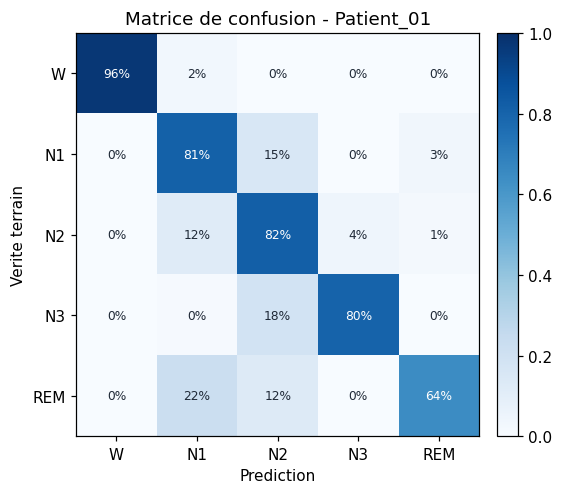

In [10]:
# Matrice de confusion (normalisee par ligne)
cm = np.array(m['confusion_matrix'], dtype=float)
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(STAGES); ax.set_yticklabels(STAGES)
ax.set_xlabel('Prediction'); ax.set_ylabel('Verite terrain')
ax.set_title('Matrice de confusion - Patient_01')
for i in range(5):
    for j in range(5):
        ax.text(j, i, '%d%%' % (cmn[i, j] * 100), ha='center', va='center',
                color='white' if cmn[i, j] > 0.5 else '#1f2937', fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

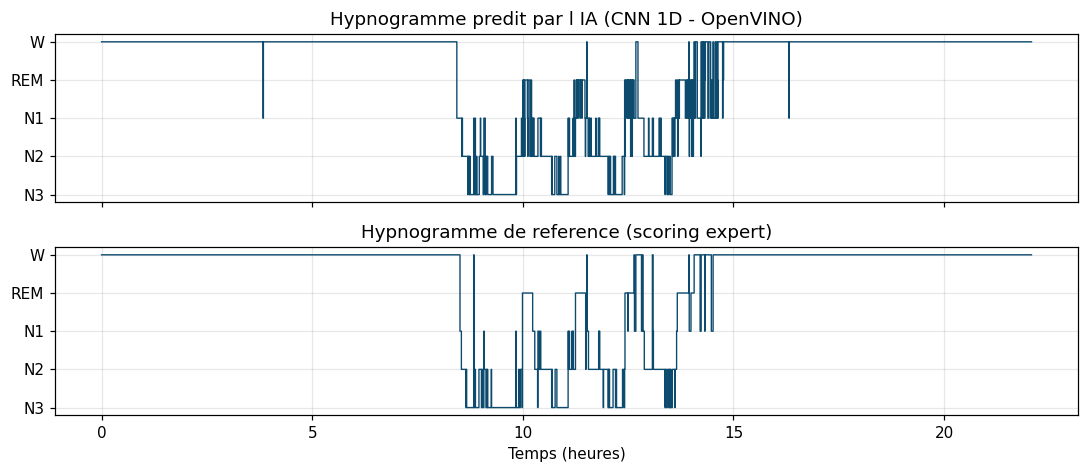

In [11]:
# Hypnogrammes : IA vs expert
hours = np.arange(n_epochs) * 30.0 / 3600.0
order = [0, 4, 1, 2, 3]
remap = {st: pos for pos, st in enumerate(order)}
fig, ax = plt.subplots(2, 1, figsize=(10, 4.4), sharex=True)

def draw(a, seq, title):
    ok = seq >= 0
    yv = np.array([remap.get(int(s), np.nan) for s in seq], float)
    a.step(hours[ok], yv[ok], where='post', color='#0C4A6E', lw=0.9)
    a.set_yticks(range(5)); a.set_yticklabels([STAGES[o] for o in order])
    a.set_title(title); a.grid(alpha=0.3); a.invert_yaxis()

draw(ax[0], preds, 'Hypnogramme predit par l IA (CNN 1D - OpenVINO)')
draw(ax[1], y_true, 'Hypnogramme de reference (scoring expert)')
ax[1].set_xlabel('Temps (heures)')
plt.tight_layout(); plt.show()

## 10. Resultats sur le jeu de test hold-out (27 sujets)

Au-dela d'un patient, le modele a ete evalue sur l'ensemble du jeu de test (27 sujets, 64 113 epoques
jamais vues) via `src/evaluate_holdout.py`. On charge les metriques sauvegardees et on les compare a la
variante CNN + Bi-LSTM.

In [12]:
def load_metrics(name):
    with open(os.path.join(ROOT, 'models', name), encoding='utf-8') as f:
        return json.load(f)

cnn = load_metrics('metrics_holdout_test.json')
bil = load_metrics('metrics_test_bilstm.json')

print('=== Jeu de test hold-out (27 sujets, %d epoques) ===\n' % cnn['n_samples'])
print('%-22s %14s %16s' % ('Metrique', 'CNN 1D (NPU)', 'CNN + Bi-LSTM'))
for label, kkey in [('Accuracy', 'accuracy'), ('F1 macro', 'f1_macro'),
                    ('F1 pondere', 'f1_weighted'), ('Kappa de Cohen', 'cohen_kappa')]:
    print('%-22s %14.3f %16.3f' % (label, cnn[kkey], bil[kkey]))

print('\nF1 par stade (CNN 1D) :')
for st in STAGES:
    print('  %-4s F1=%.3f  rappel=%.3f  (n=%d)'
          % (st, cnn['per_class'][st]['f1'], cnn['per_class'][st]['recall'], cnn['per_class'][st]['support']))

=== Jeu de test hold-out (27 sujets, 64113 epoques) ===

Metrique                 CNN 1D (NPU)    CNN + Bi-LSTM
Accuracy                        0.859            0.837
F1 macro                        0.738            0.700
F1 pondere                      0.870            0.851
Kappa de Cohen                  0.756            0.719

F1 par stade (CNN 1D) :
  W    F1=0.961  rappel=0.926  (n=40828)
  N1   F1=0.445  rappel=0.604  (n=3971)
  N2   F1=0.775  rappel=0.736  (n=11658)
  N3   F1=0.747  rappel=0.840  (n=2785)
  REM  F1=0.762  rappel=0.808  (n=4871)


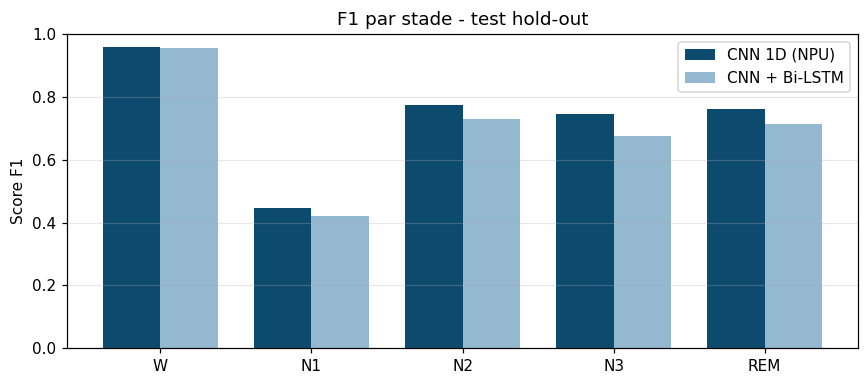

In [13]:
# Comparaison F1 par stade
cnn_f1 = [cnn['per_class'][s]['f1'] for s in STAGES]
bil_f1 = [bil['per_class'][s]['f1'] for s in STAGES]
x = np.arange(5); w = 0.38
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x - w / 2, cnn_f1, w, label='CNN 1D (NPU)', color='#0C4A6E')
ax.bar(x + w / 2, bil_f1, w, label='CNN + Bi-LSTM', color='#94B8D0')
ax.set_xticks(x); ax.set_xticklabels(STAGES); ax.set_ylim(0, 1)
ax.set_ylabel('Score F1'); ax.set_title('F1 par stade - test hold-out')
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 11. Conclusion

Le projet **Sommeil_EOG_IA** demontre une chaine de bout en bout reproductible :

- **Donnees** standardisees (EDF / AASM) et pretraitement robuste d'un unique canal EOG.
- **Modele** CNN 1D evalue rigoureusement par **decoupage par sujet** (pas de fuite de donnees).
- **Performances** sur 27 sujets de test : exactitude ~85,9 %, F1 macro ~0,738, kappa ~0,756
  (accord *substantiel* avec l'expert), surpassant la variante CNN + Bi-LSTM.
- **Deploiement** optimise via OpenVINO (NPU / GPU / CPU) et **dashboard** clinique Streamlit.

Le stade **N1** reste le plus difficile (transition courte et minoritaire), ce qui est attendu et
documente dans la litterature. Perspectives : approche multi-canaux, agregation temporelle
sequence-a-sequence et explicabilite (Grad-CAM).

> **Pour lancer le dashboard :** `streamlit run app/dashboard.py` (depuis la racine du projet).